In [51]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [52]:
#Importing all 3 files, grouping them to see each contributor's total contribution, and sorting them in descending order.
#Replace csv names with the names of your files. 
df1 = pd.read_csv('low-republican/Celeste Maloy.csv')
df1 = df1.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)

df2 = pd.read_csv('low-republican/John Trent Kelly.csv')
df2 = df2.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)

df3 = pd.read_csv('low-republican/Neal Patrick Dunn.csv')
df3 = df3.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)

dfs = [df1, df2, df3]   


In [72]:
df1.head(10)

,contributor_name,contribution_receipt_amount,stance,target
296,TEAM CELESTE,21700.00,gray,Celeste Maloy
326,WINRED,16550.00,gray,Celeste Maloy
101,ES3 PAC,15000.00,gray,Celeste Maloy
21,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE,14625.00,gray,Celeste Maloy
22,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLIT...,14500.00,gray,Celeste Maloy
124,GOP WINNING WOMEN 2026,14092.56,gray,Celeste Maloy
37,"BAILEY, BRETT",10500.00,gray,Celeste Maloy
266,"ROBBINS, LYNN G.",10500.00,gray,Celeste Maloy
239,"PELESSONE, LUKE",10500.00,gray,Celeste Maloy
183,"MANNING, PATRICK",10500.00,gray,Celeste Maloy


In [54]:
df2.head(10)

,contributor_name,contribution_receipt_amount
338,WINRED,95232.02
311,THE FARM CREDIT COUNCIL POLITICAL ACTION COMMI...,10000.00
310,THE BOEING COMPANY POLITICAL ACTION COMMITTEE,10000.00
298,"STINSON, KENNETH E",7000.00
180,"LEE, FRANCIS C",7000.00
261,"RICKETTS, J PETER",7000.00
181,"LEE, SHIRLEY",7000.00
334,WEYERHAEUSER COMPANY POLITICAL ACTION COMMITTEE,7000.00
274,"SEEMANN, IV, WILLIAM H",7000.00
133,"GENTRY, JAMES",6600.00


In [55]:
df3.head(10)

,contributor_name,contribution_receipt_amount
227,DUNN VICTORY FUND,133127.97
728,WINRED,129110.00
51,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLIT...,21725.00
115,BILIRAKIS DUNN VICTORY FUND,11030.10
523,OUTPATIENT ENDOVASCULAR & INTERVENTIONAL SOCIE...,10000.00
17,ALLIANCE FOR PHYSICAL THERAPY QUALITY AND INNO...,10000.00
309,GUIDEWELL MUTUAL HOLDING CORPORATION POLITICAL...,10000.00
569,"REAVES, TODD",7000.00
669,"THOMAS, CRAIG M. MR.",7000.00
500,NEWLIGHT HEALTHCARE LLC,7000.00


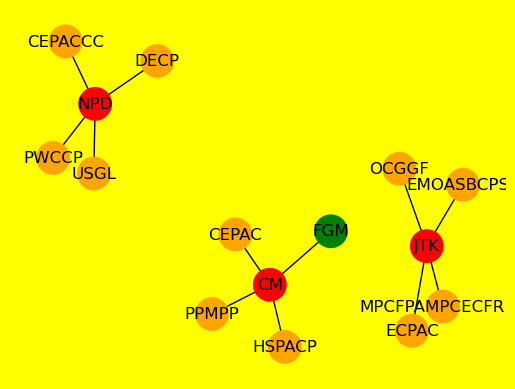

In [83]:
#This is where you place all of the information about the congress members! Include their names, and the funders/ donors that you chose (in their respected categories ofc)
#This is all you really need to change. IF you are working with Democrats, look for the other comment in the loop and change the color to "skyblue" (or whatever color you prefer ). 
members = [
    {
        "name": "Celeste Maloy",
        "fossil": ["PACIFICORP-PACIFIC POWER/ROCKY MOUNTAIN POWER PAC", 
                   "CHEVRON EMPLOYEES POLITICAL ACTION COMMITTEE", 
                   "HF SINCLAIR POLITICAL ACTION COMMITTEE (DINO PAC)"],
        "green": ["FRENCH GATES, MELINDA"]
    },
    {
        "name": "John Trent Kelly",
        "fossil": ["MISSISSIPPI POWER COMPANY FEDERAL PAC A/K/A/ MS PWR CO EMP COMM FOR RESP FED GOV", 
                   "ENTERGY CORPORATION POLITICAL ACTION COMMITTEE (ENPAC)", 
                   "OLIN CORPORATION GOOD GOVERNMENT FUND", 
                   "ENERGY MARKETERS OF AMERICA SMALL BUSINESS COMMITTEE PAC (EMA SBC PAC)"],
        "green": []
    },
    {
        "name": "Neal Patrick Dunn",
        "fossil": ["UTILITY SOLUTIONS GROUP LLC", 
                   "DUKE ENERGY CORPORATION PAC", 
                   "CHEVRON EMPLOYEES POLITICAL ACTION COMMITTEE - CHEVRON CORPO", 
                   "PINNACLE WEST CAPITAL CORPORATION PAC"],
        "green": []
    }
]

Gs = [nx.Graph(), nx.Graph(), nx.Graph()]

for i, (df, m) in enumerate(zip(dfs, members)):
    df["stance"] = "gray"
    df["target"] = m["name"]

    #Play around with these colors if you'd like, defaults are orange and green.
    df.loc[df["contributor_name"].isin(m["fossil"]), "stance"] = "orange"
    df.loc[df["contributor_name"].isin(m["green"]), "stance"] = "green"

    Gs[i] = nx.from_pandas_edgelist(df[df["contributor_name"].isin(m["fossil"] + m["green"])], source="contributor_name", target="target", edge_attr=["stance"])

    for _, row in df.iterrows():
        if row["contributor_name"] in Gs[i].nodes:
            Gs[i].nodes[row["contributor_name"]]["color"] = row["stance"]

    #If working with Democrats, change to "skyblue"
    # Ensure the member node exists before coloring it.
    if m["name"] not in Gs[i].nodes:
        Gs[i].add_node(m["name"])
    Gs[i].nodes[m["name"]]["color"] = "red"

G1 = Gs[0]
G1.add_nodes_from(Gs[1].nodes(data=True))
G1.add_nodes_from(Gs[2].nodes(data=True))
G1.add_edges_from(Gs[1].edges(data=True))
G1.add_edges_from(Gs[2].edges(data=True))

key = []
labels = {}
for n in G1.nodes():
    parts = n.split() 
    letters = [p[0] for p in parts if p[0].isalpha()]
    labels[n] = "".join(letters)
    key.append({labels[n] : n})


node_colors = [G1.nodes[n].get("color", "gray") for n in G1.nodes()]

fig, ax = plt.subplots()
pos = nx.spring_layout(G1, k=1, iterations=100)
nx.draw(G1, pos=pos, with_labels=True, labels=labels, node_color=node_colors, node_size=500, edge_color='black', linewidths=2)
ax.axis('off')
#You can change the background color here. 
fig.set_facecolor('yellow')
plt.show()

In [ ]:
print("Key: ")
for item in key:
    for k, v in item.items( ):
        print(f"{k} = {v}") 


Key: 
PPMPP = PACIFICORP-PACIFIC POWER/ROCKY MOUNTAIN POWER PAC
CM = Celeste Maloy
CEPAC = CHEVRON EMPLOYEES POLITICAL ACTION COMMITTEE
FGM = FRENCH GATES, MELINDA
HSPACP = HF SINCLAIR POLITICAL ACTION COMMITTEE (DINO PAC)
MPCFPAMPCECFRFG = MISSISSIPPI POWER COMPANY FEDERAL PAC A/K/A/ MS PWR CO EMP COMM FOR RESP FED GOV
JTK = John Trent Kelly
ECPAC = ENTERGY CORPORATION POLITICAL ACTION COMMITTEE (ENPAC)
OCGGF = OLIN CORPORATION GOOD GOVERNMENT FUND
EMOASBCPSP = ENERGY MARKETERS OF AMERICA SMALL BUSINESS COMMITTEE PAC (EMA SBC PAC)
USGL = UTILITY SOLUTIONS GROUP LLC
NPD = Neal Patrick Dunn
DECP = DUKE ENERGY CORPORATION PAC
PWCCP = PINNACLE WEST CAPITAL CORPORATION PAC
